#**Wine Quality Prediction**


##**Objective**

Train and compare multiple classification models to predict the quality score of wine (typically a scale of 3–8) based on its physicochemical properties such as acidity, density, and alcohol content.


###**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

###**Load the Dataset**

In [ ]:
df = pd.read_csv('/content/winequality-red.csv')

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.shape

(1599, 12)

In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


###**Check Missing Values and Duplicates**

In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
df.duplicated().sum()

np.int64(240)

In [ ]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [ ]:
df['quality'].value_counts().sort_index()

,count
quality,
3,10
4,53
5,681
6,638
7,199
8,18


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(1359, 12)

###**Analyze the Quality Distribution**

In [ ]:
quality_counts = df['quality'].value_counts().sort_index()

print(quality_counts)

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


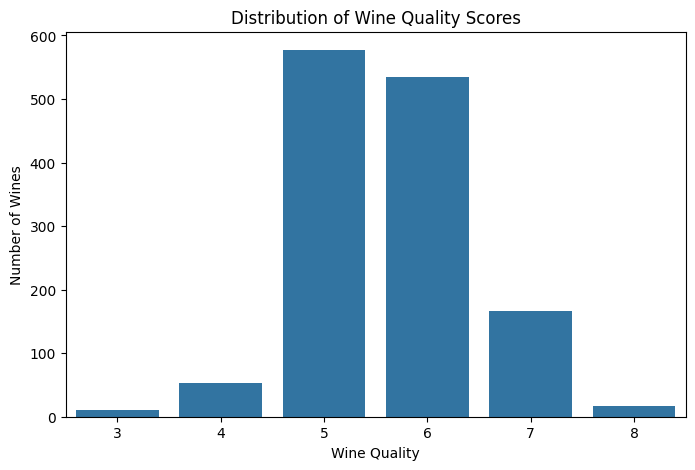

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='quality',
    order=sorted(df['quality'].unique())
)

plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Wine Quality')
plt.ylabel('Number of Wines')
plt.show()

###**EDA: Chemical Feature Distributions**

In [ ]:
features = df.drop(columns=['quality']).columns

print(features)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')


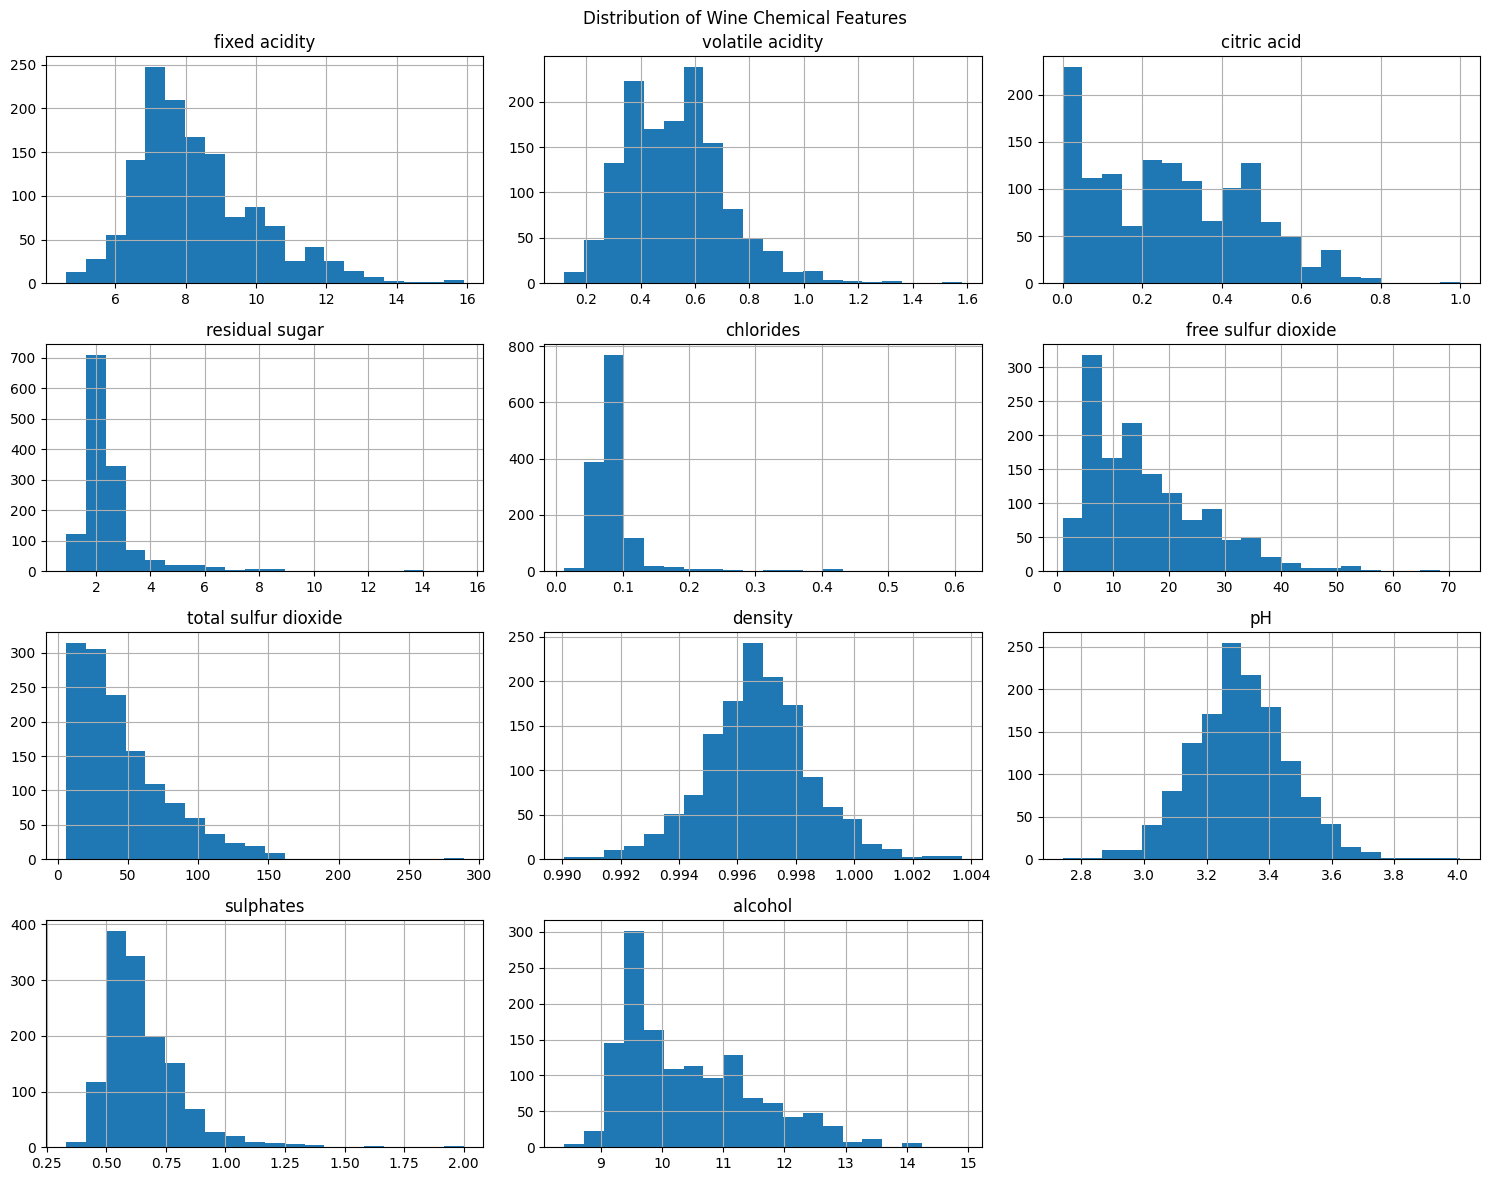

In [ ]:
df[features].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle('Distribution of Wine Chemical Features')
plt.tight_layout()
plt.show()

###**Correlation Heatmap**

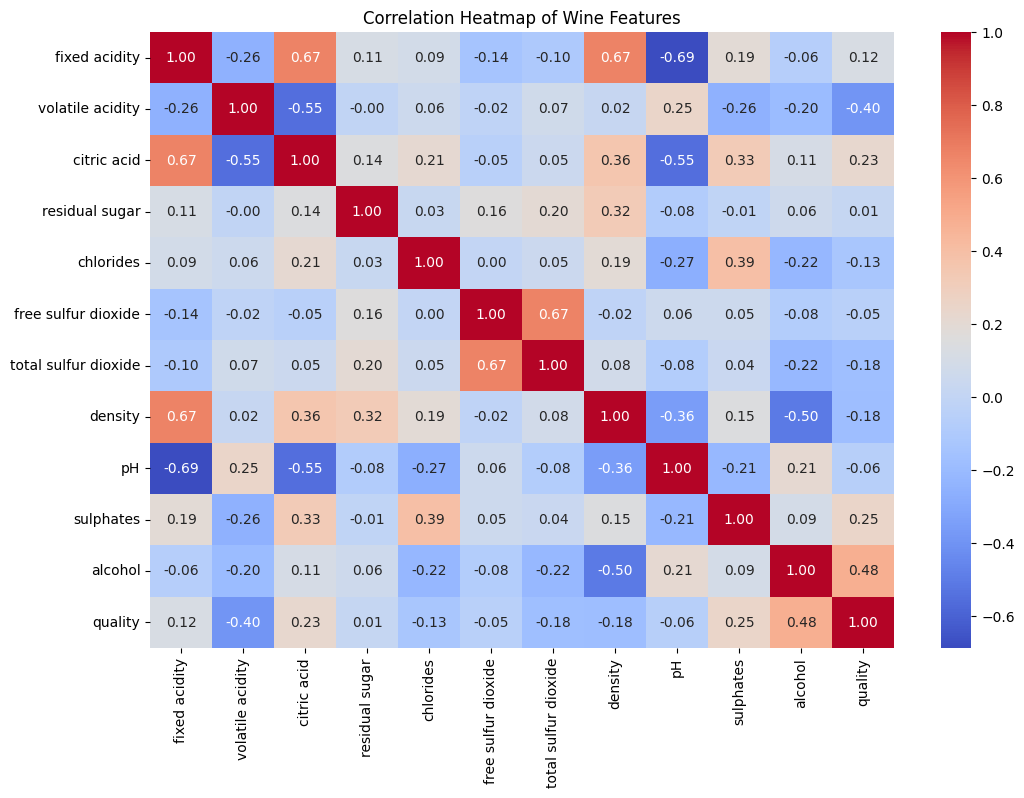

In [ ]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Wine Features')
plt.show()

In [ ]:
quality_correlation = df.corr()['quality'].sort_values(ascending=False)

print(quality_correlation)

quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64


###**Class Imbalance**

In [ ]:
quality_percentage = (
    df['quality']
    .value_counts(normalize=True)
    .sort_index() * 100
)

print(quality_percentage.round(2))

quality
3     0.74
4     3.90
5    42.46
6    39.37
7    12.29
8     1.25
Name: proportion, dtype: float64


###**Feature Engineering: Converting Quality into 3 Classes**

In [ ]:
def categorize_quality(quality):
    if quality <= 4:
        return 'Low'
    elif quality <= 6:
        return 'Medium'
    else:
        return 'High'

df['quality_category'] = df['quality'].apply(categorize_quality)

In [ ]:
df['quality_category'].value_counts()

,count
quality_category,
Medium,1112
High,184
Low,63


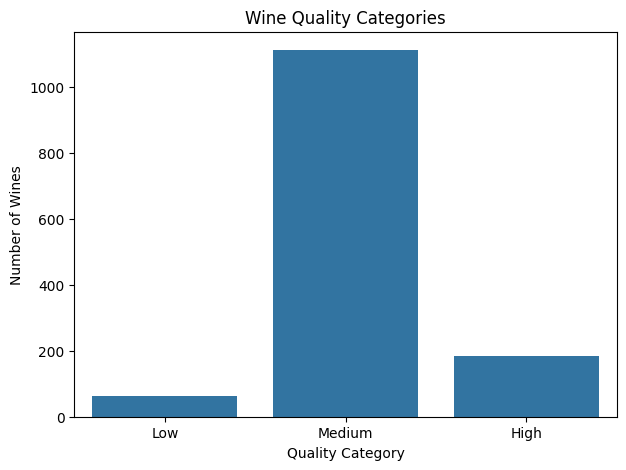

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='quality_category',
    order=['Low', 'Medium', 'High']
)

plt.title('Wine Quality Categories')
plt.xlabel('Quality Category')
plt.ylabel('Number of Wines')
plt.show()

###**Prepare X and y**

In [ ]:
X = df.drop(columns=['quality', 'quality_category'])

y = df['quality_category']

In [ ]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1359, 11)
Target shape: (1359,)


In [ ]:
print(y.value_counts())

quality_category
Medium    1112
High       184
Low         63
Name: count, dtype: int64


###**Train/Test Split with Stratification**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
quality_category
Medium    0.818767
High      0.135235
Low       0.045998
Name: proportion, dtype: float64

Testing distribution:
quality_category
Medium    0.816176
High      0.136029
Low       0.047794
Name: proportion, dtype: float64


###**Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###**Train Random Forest**

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8198529411764706


###**Train SGD Classifier**

In [ ]:
sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(X_train_scaled, y_train)

SGDClassifier(random_state=42)

In [ ]:
sgd_pred = sgd_model.predict(X_test_scaled)

In [ ]:
sgd_accuracy = accuracy_score(y_test, sgd_pred)

print("SGD Accuracy:", sgd_accuracy)

SGD Accuracy: 0.8051470588235294


###**Train SVC**

In [ ]:
svc_model = SVC(
    kernel='rbf',
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [ ]:
svc_pred = svc_model.predict(X_test_scaled)

In [ ]:
svc_accuracy = accuracy_score(y_test, svc_pred)

print("SVC Accuracy:", svc_accuracy)

SVC Accuracy: 0.8455882352941176


###**Classification Reports**

In [ ]:
print("Random Forest Classification Report")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report
              precision    recall  f1-score   support

        High       0.57      0.32      0.41        37
         Low       0.33      0.15      0.21        13
      Medium       0.85      0.94      0.90       222

    accuracy                           0.82       272
   macro avg       0.59      0.47      0.51       272
weighted avg       0.79      0.82      0.80       272



In [ ]:
print("SGD Classification Report")
print(classification_report(y_test, sgd_pred))

SGD Classification Report
              precision    recall  f1-score   support

        High       0.44      0.41      0.42        37
         Low       1.00      0.08      0.14        13
      Medium       0.86      0.91      0.88       222

    accuracy                           0.81       272
   macro avg       0.77      0.47      0.48       272
weighted avg       0.81      0.81      0.79       272



In [ ]:
print("SVC Classification Report")
print(classification_report(y_test, svc_pred))

SVC Classification Report
              precision    recall  f1-score   support

        High       0.90      0.24      0.38        37
         Low       0.00      0.00      0.00        13
      Medium       0.84      1.00      0.91       222

    accuracy                           0.85       272
   macro avg       0.58      0.41      0.43       272
weighted avg       0.81      0.85      0.80       272



###**Confusion Matrices**

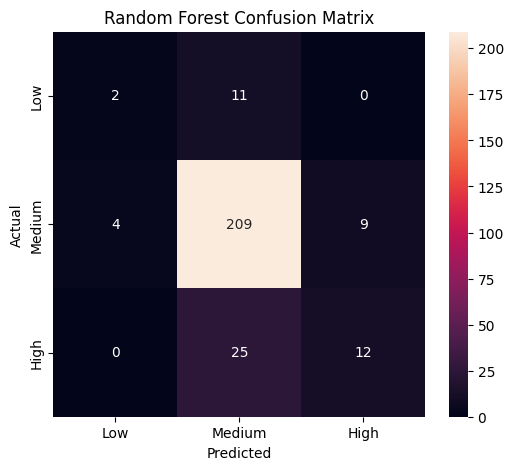

In [ ]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred,
    labels=['Low', 'Medium', 'High']
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

###**Random Forest Feature Importance**

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

In [ ]:
print(feature_importance)

alcohol                 0.151730
volatile acidity        0.117394
sulphates               0.113169
density                 0.091047
total sulfur dioxide    0.089182
citric acid             0.082148
fixed acidity           0.078966
residual sugar          0.076459
chlorides               0.069741
pH                      0.068442
free sulfur dioxide     0.061721
dtype: float64


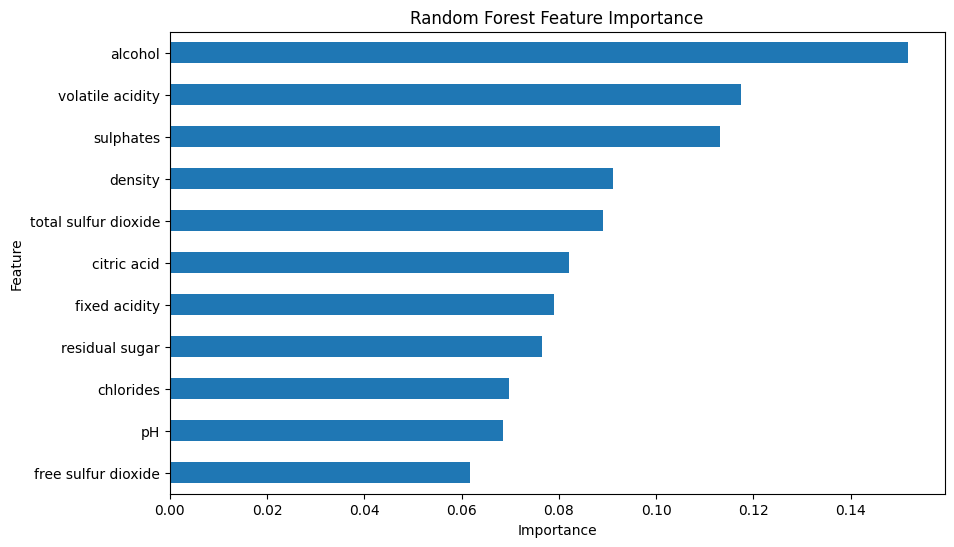

In [ ]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind='barh')

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

###**Model Comparison Table**

In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'SGD Classifier',
        'SVC'
    ],
    'Accuracy': [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.819853
1,SGD Classifier,0.805147
2,SVC,0.845588


In [ ]:
from sklearn.metrics import f1_score

rf_f1 = f1_score(y_test, rf_pred, average='weighted')
sgd_f1 = f1_score(y_test, sgd_pred, average='weighted')
svc_f1 = f1_score(y_test, svc_pred, average='weighted')

comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'SGD Classifier',
        'SVC'
    ],
    'Accuracy': [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ],
    'Weighted F1-Score': [
        rf_f1,
        sgd_f1,
        svc_f1
    ]
})

comparison.sort_values(
    by='Weighted F1-Score',
    ascending=False
)

,Model,Accuracy,Weighted F1-Score
2,SVC,0.845588,0.797448
0,Random Forest,0.819853,0.796889
1,SGD Classifier,0.805147,0.786239


## Conclusion

Three classification models were trained on the data to predict wine quality classification:
Random Forest, SGD Classifier, and SVC.

The initial quality scores were binned into three categories:
Low, Medium, and High. This approach allowed to make the problem more practical
and reduce the number of sparse categories.

Of the three models, [BEST MODEL] demonstrated the best performance with an accuracy of [X] and a weighted F1-score of [Y].

The feature importance analysis conducted on the Random Forest classifier revealed that [TOP FEATURES]
had the most predictive power.

According to the analysis results, [BEST MODEL] should be preferred for implementation since it demonstrated the best performance in terms of accuracy on the test set.